In [98]:
import pandas as pd 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,RobustScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.pipeline import  Pipeline
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [99]:
df=pd.read_csv("customer_segmentation.csv")

In [100]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [102]:
col=df.columns
col

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [103]:
for i in col:
    print(i,":",df[i].nunique())


ID : 2240
Year_Birth : 59
Education : 5
Marital_Status : 8
Income : 1974
Kidhome : 3
Teenhome : 3
Dt_Customer : 663
Recency : 100
MntWines : 776
MntFruits : 158
MntMeatProducts : 558
MntFishProducts : 182
MntSweetProducts : 177
MntGoldProds : 213
NumDealsPurchases : 15
NumWebPurchases : 15
NumCatalogPurchases : 14
NumStorePurchases : 14
NumWebVisitsMonth : 16
AcceptedCmp3 : 2
AcceptedCmp4 : 2
AcceptedCmp5 : 2
AcceptedCmp1 : 2
AcceptedCmp2 : 2
Complain : 2
Z_CostContact : 1
Z_Revenue : 1
Response : 2


<Axes: >

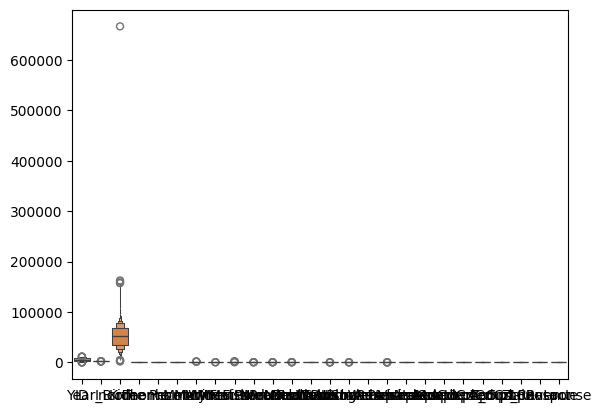

In [104]:
sns.boxenplot(df)

In [105]:
df=df.drop(columns=["Z_CostContact","Z_Revenue"])

In [106]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],format="%d-%m-%Y")
df["customer_Day"]=df["Dt_Customer"].dt.day 
df["customer_month"]=df["Dt_Customer"].dt.month 
df.drop("Dt_Customer",axis=1,inplace=True)

In [107]:
df=df.dropna()

In [108]:
num_col=df.select_dtypes(include="number").columns
obj_col=df.select_dtypes(exclude="number").columns

In [109]:
preprocessing=ColumnTransformer(
    transformers=[
        ("scaler",StandardScaler(),num_col),
        ("OrdinalEncoder",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1),obj_col)
    ]
)

In [122]:
pipeline=Pipeline(
    steps=[
        ("preprocessing",preprocessing),
        ("model",KMeans(n_clusters=2))
    ]
)

In [123]:
res=pipeline.fit_predict(df)

In [124]:
df["result"]=res

In [125]:
group=df.groupby("result")

In [126]:
group

In [127]:
group.get_group(0)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,customer_Day,customer_month,result
1,2174,1954,Graduation,Single,46344.0,1,1,38,11,1,...,0,0,0,0,0,0,0,8,3,0
3,6182,1984,Graduation,Together,26646.0,1,0,26,11,4,...,0,0,0,0,0,0,0,10,2,0
4,5324,1981,PhD,Married,58293.0,1,0,94,173,43,...,0,0,0,0,0,0,0,19,1,0
7,6177,1985,PhD,Married,33454.0,1,0,32,76,10,...,0,0,0,0,0,0,0,8,5,0
8,4855,1974,PhD,Together,30351.0,1,0,19,14,0,...,0,0,0,0,0,0,1,6,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2230,7004,1984,Graduation,Single,11012.0,1,0,82,24,3,...,1,0,0,0,0,0,0,16,3,0
2232,8080,1986,Graduation,Single,26816.0,0,0,50,5,1,...,0,0,0,0,0,0,0,17,8,0
2234,8372,1974,Graduation,Married,34421.0,1,0,81,3,3,...,0,0,0,0,0,0,0,1,7,0
2236,4001,1946,PhD,Together,64014.0,2,1,56,406,0,...,0,0,0,1,0,0,0,10,6,0


In [128]:
group.get_group(1)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,customer_Day,customer_month,result
0,5524,1957,Graduation,Single,58138.0,0,0,58,635,88,...,0,0,0,0,0,0,1,4,9,1
2,4141,1965,Graduation,Together,71613.0,0,0,26,426,49,...,0,0,0,0,0,0,0,21,8,1
5,7446,1967,Master,Together,62513.0,0,1,16,520,42,...,0,0,0,0,0,0,0,9,9,1
6,965,1971,Graduation,Divorced,55635.0,0,1,34,235,65,...,0,0,0,0,0,0,0,13,11,1
12,2125,1959,Graduation,Divorced,63033.0,0,0,82,194,61,...,0,0,0,0,0,0,0,15,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,9817,1970,Master,Single,44802.0,0,0,71,853,10,...,0,0,0,0,0,0,0,21,8,1
2233,9432,1977,Graduation,Together,666666.0,1,0,23,9,14,...,0,0,0,0,0,0,0,2,6,1
2235,10870,1967,Graduation,Married,61223.0,0,1,46,709,43,...,0,0,0,0,0,0,0,13,6,1
2237,7270,1981,Graduation,Divorced,56981.0,0,0,91,908,48,...,0,1,0,0,0,0,0,25,1,1


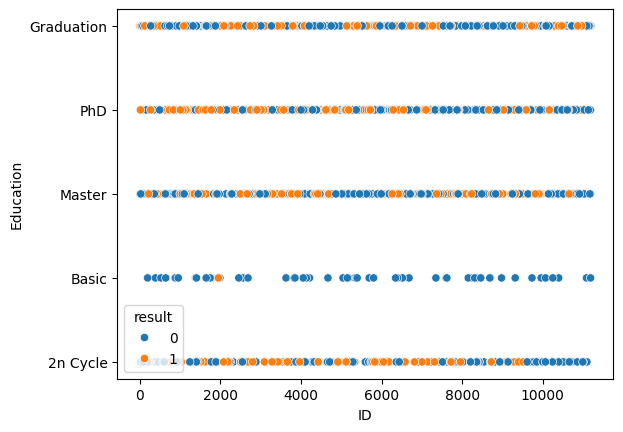

In [129]:
sns.scatterplot(x=df["ID"],y=df["Education"],hue=df['result'])
plt.show()

PCA

In [130]:
preprocessing=ColumnTransformer(
    transformers=[
        ("scaler",StandardScaler(),num_col),
        ("OrdinalEncoder",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1),obj_col)
    ]
)

In [131]:
pipeline=Pipeline(
    steps=[
        ("preprocessing",preprocessing),
        ("model",PCA(n_components=2))
    ]
)

In [132]:
c=pipeline.fit_transform(df)

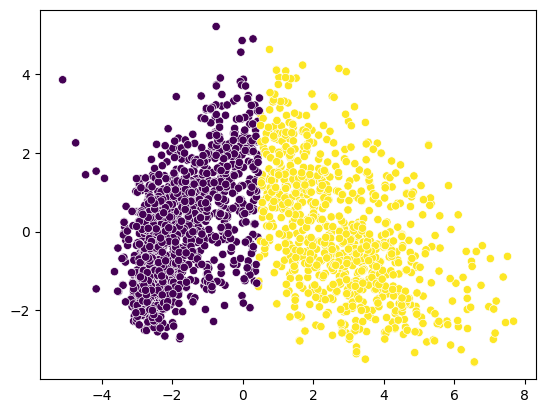

In [133]:
sns.scatterplot(x=c[:, 0],y=c[:, 1],c=df['result'])
plt.show()